<a href="https://colab.research.google.com/github/ara1420/Ara14.github.io/blob/main/%E6%9A%97%E5%8F%B7%E7%90%86%E8%AB%962026_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 秘密分散法に基づく秘匿計算ライブラリ csclib
スタンドアロンモードとマルチパーティモード
1. スタンドアロンモード
   1台のマシンで計算（つまり秘匿計算ではない）．
   これで正しく計算できればマルチパーティモードでも動くはず．
2. マルチパーティモード
   パーティ0, 1, 2 で通信をしながら計算を行う．パーティ 1, 2 は計算中の値の情報を得ない．パーティ0 はパーティ 1, 2 から計算結果を受け取り答えを得る．


# インストール
pip で PyPI から csclib をインストール．

自分の計算機に pip でインストールすればマルチパーティモードも利用可能．

自分の計算機にインストールする場合，

```
python3 -m venv env
source env/bin/activate
pip install csclib
```

とする．


In [ ]:
!pip install --upgrade csclib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 1.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for csclib: filename=csclib-202607311-cp313-cp313-linux_x86_64.whl size=846175 sha256=2d2ad0526061c98edfcc1d67182b824d4d03ed092e3cb22de8dfce6f11e2c518
  Stored in directory: /root/.cache/pip/wheels/e1/83/de/7cdbe95083ea70f9170fee9a9cf05ba5a2ab2a95805bf70093
Successfully built csclib


# クラス
加法的秘密分散法では，整数 x を (r, x-r) という整数のペアで表す．
演算は mod q で行われる．q は任意の自然数だが，演算によっては q は2のべき乗である必要がある．

csclib では大規模データの処理を想定しているため，データ構造は全てシェアの配列となっている．以下の2つがある．

*   Share
    シェアの配列で，mod q で計算する．
*   Bits
    シェアの配列だが，配列の各要素を2進数で表現し，各桁を mod q の加法的シェア（つまり上の Share）で表す．値を表現するには q は 2 で良いが，各種演算を行うためには元の値を表現可能な2のべき乗にする必要がある．


In [ ]:
from csclib import * # ライブラリのインポート


if __name__ == '__main__':
  party = -1 # スタンドアロンモード
  Csclib_start(party) # 最初に必ず実行する．

  A = [0, 1, 2, 3] # 通常のPythonの配列

  q = 8
  sA = Share(A, q) # mod q のシェアの配列を作成
  print('A', sA)
  print('length of A is', sA.len()) # len(sA) も可
  print('order of A is', sA.order())

  B = [4, 3, 2, 1] # 通常のPythonの配列
  sB = Share(B, q)
  print('B', sB)

  sC = sB.reconstruct() # パーティからシェアをもらって値を復元
  print('C', sC)

  D = sC.get() # Python の配列に戻す (reconstructはしない)
  print('D', D)



A n = 4 q = 8 w = 3 irr = 0 party -1: 0 1 2 3 
length of A is 4
order of A is 8
B n = 4 q = 8 w = 3 irr = 0 party -1: 4 3 2 1 
C n = 4 q = 8 w = 3 irr = 0 party -1: 4 3 2 1 
D [4, 3, 2, 1]


# 基本的な演算

多くの演算は，配列の各要素に対して独立に行われる．演算の結果もシェアの配列である．


In [ ]:
  #test02.py
  q = 16

  x = Share([1,2,3], q)
  print("x", x)

  y = Share([4,5,6], q)
  print("y", y)

  z = x + y
  print("z", z)




x n = 3 q = 16 w = 4 irr = 0 party -1: 1 2 3 
y n = 3 q = 16 w = 4 irr = 0 party -1: 4 5 6 
z n = 3 q = 16 w = 4 irr = 0 party -1: 5 7 9 


In [ ]:
  #test03.py
  q = 16

  x = Share([1,2,3], q)
  print("x", x)

  y = [4,5,6] # 平文
  print("y", y)

  z = x + y
  print("z", z)

  w = 2 * x
  print("w", w)


x n = 3 q = 16 w = 4 irr = 0 party -1: 1 2 3 
y [4, 5, 6]
z n = 3 q = 16 w = 4 irr = 0 party -1: 5 7 9 
w n = 3 q = 16 w = 4 irr = 0 party -1: 2 4 6 


In [ ]:
  #test04.py
  q = 16

  x = Share([1,2,3], q)
  print("x", x)

  y = Share([4,5,6], q)
  print("y", y)

  z = x * y
  print("z", z)


x n = 3 q = 16 w = 4 irr = 0 party -1: 1 2 3 
y n = 3 q = 16 w = 4 irr = 0 party -1: 4 5 6 
z n = 3 q = 16 w = 4 irr = 0 party -1: 4 10 2 


足し算，定数倍を自分で実装

In [ ]:
#ADD.py
import sys
from csclib import *

def ADD(x, y):
  q = x.order()
  n = len(x)

  x_raw = x.get() # シェアから生の配列を取り出す
  y_raw = y.get()
  z_raw = [0] * n

  for i in range(n):
    z_raw[i] = (x_raw[i] + y_raw[i]) % q

  z = Share().const(n, 0, q) # 答えを格納するシェアを作る
  z.set(z_raw) # シェアに生の配列を入れる

  return z

def SMul(a, x):
  q = x.order()
  n = len(x)

  x_raw = x.get()
  z_raw = [0] * n

  for i in range(n):
    z_raw[i] = (a * x_raw[i]) % q

  z = Share().const(n, 0, q)
  z.set(z_raw)

  return z


x = Share([1, 2, 3], 16)
y = Share([4, 5, 6], 16)

z = ADD(x, y)
print("z = ", z)
z.check()

w = SMul(2, x)
print("w = ", w)


z =  n = 3 q = 16 w = 4 irr = 0 party -1: 5 7 9 
w =  n = 3 q = 16 w = 4 irr = 0 party -1: 2 4 6 


# 配列の連結・分割（スライス）
配列の添え字は公開値である．

添え字にシェアで表された値を使う場合は，別の関数を用いる必要がある（後述）．

なお，スライスは配列の複製をしている．

In [ ]:
  sF = sA @ sB # 2つの配列を連結．同じ q でなければならない．
  print('F', sF)

  sG = sF @ [7, 7, 7] # 通常の配列も連結できる．
  print('G', sG)

  sH = 7 @ sG # 通常の整数も連結できる．
  print('H', sH)

  sI = sH[1:5] # 部分配列を取り出す
  print('I', sI)



F n = 8 q = 8 w = 3 irr = 0 party -1: 0 1 2 3 4 3 2 1 
G n = 11 q = 8 w = 3 irr = 0 party -1: 0 1 2 3 4 3 2 1 7 7 7 
H n = 12 q = 8 w = 3 irr = 0 party -1: 7 0 1 2 3 4 3 2 1 7 7 7 
I n = 4 q = 8 w = 3 irr = 0 party -1: 0 1 2 3 


# 配列の個別の要素の読み書き

In [ ]:
  sI[0] = 4 # 公開値を入れる
  print('I', sI)

  sI[1:4] = 5 # 全て同じ公開値を入れる
  print('I', sI)

  sI[0:4] = sG # sI の指定した位置に sG の先頭からの要素をコピー．sG の長さはコピーする長さ以上である必要がある．右辺は Share のスライスでも良い．
  print('I', sI)


I n = 4 q = 8 w = 3 irr = 0 party -1: 4 1 2 3 
I n = 4 q = 8 w = 3 irr = 0 party -1: 4 5 5 5 
I n = 4 q = 8 w = 3 irr = 0 party -1: 0 1 2 3 


# マルチパーティモード
マルチパーティモードで実行するには，ターミナルを複数開く必要がある．
画面下の「ターミナル」をクリックする．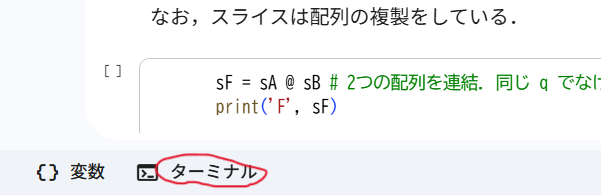

ターミナルの画面で ctrl+b を押してから % を押すとウィンドウが1つ増える．
ウィンドウを3つにする．
マルチパーティモードで実行する場合はターミナルの方の画面を使う．ターミナル間を移動するには ctrl+b を押してから矢印キーで移動する．
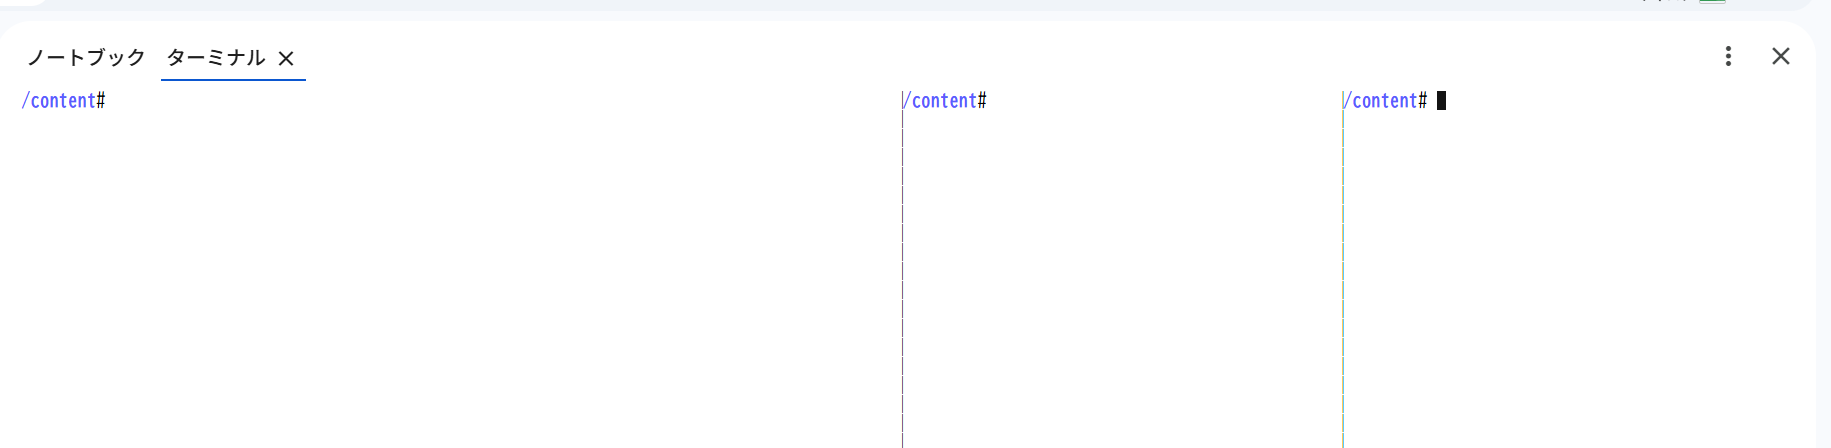

config.txt と実行したい Python ファイルをアップロードする．
実行はターミナルの画面で行う．

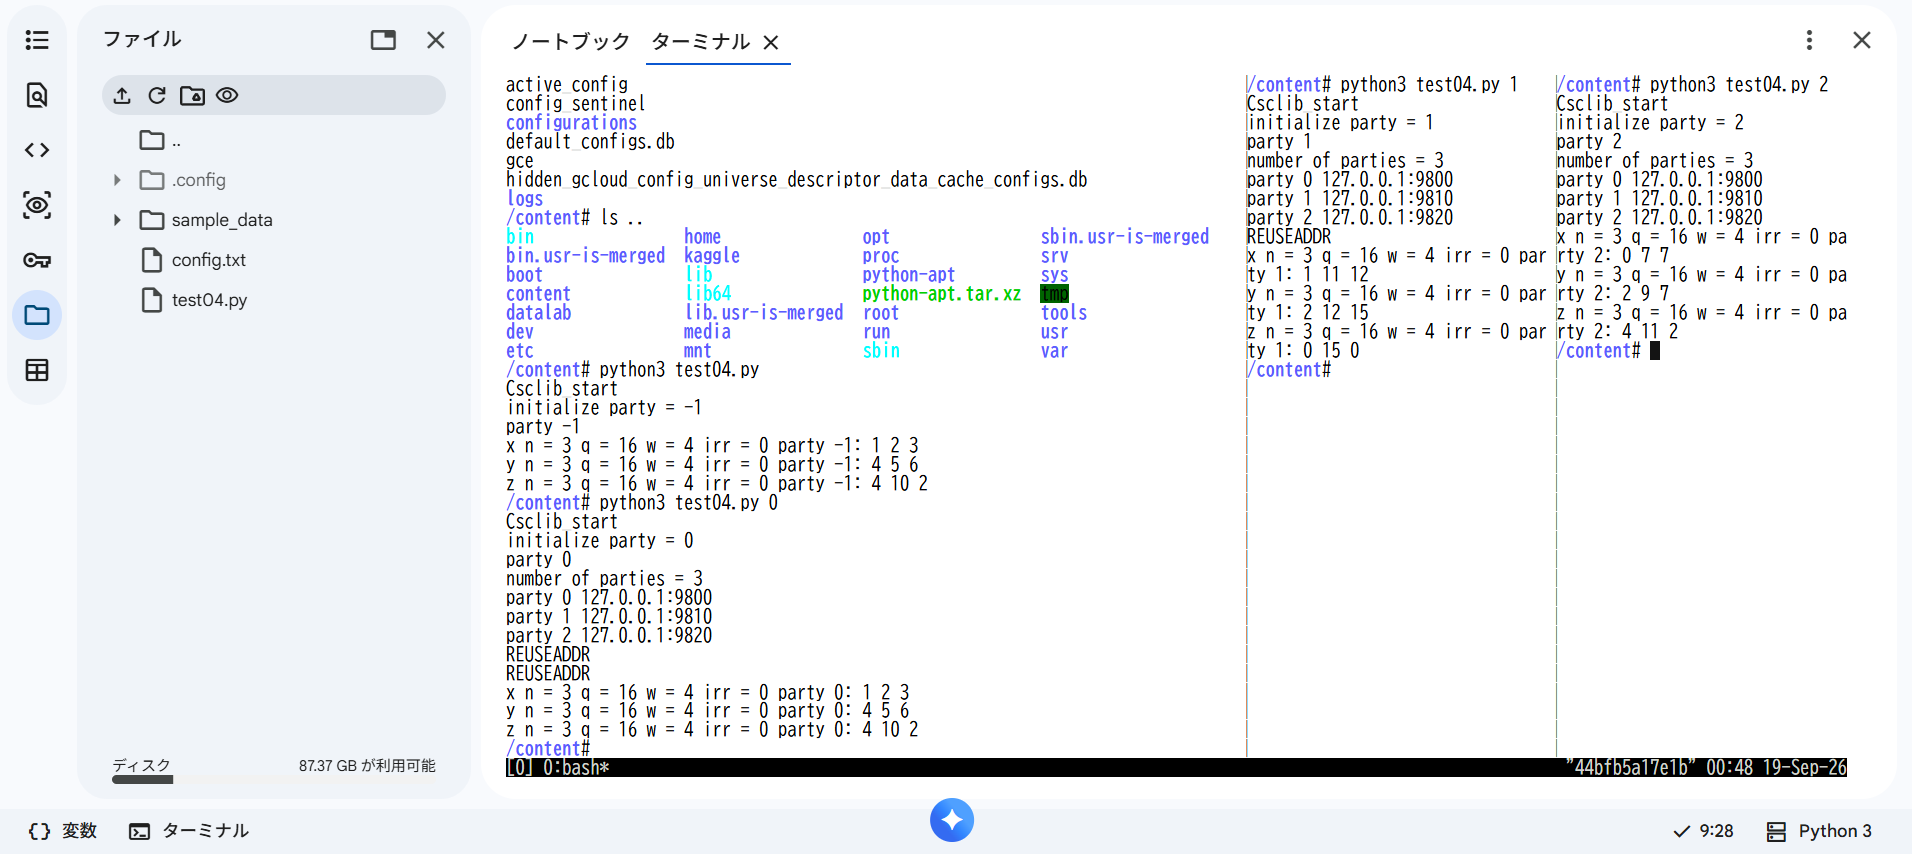

config.txt には最低限，次のように書く．

```
[options]
parties 3                   # number of parties (party 0, 1, 2)
[parties]
127.0.0.1 9800 # server      # IP address and port number for party 0
127.0.0.1 9810 # party 1     # IP address and port number for party 1
127.0.0.1 9820 # party 2     # IP address and port number for party 2
```





party 0 は平文（暗暗号化無し）で計算する．
party 0 が値のシェアを作って party 1, 2 に送信する．

# 条件文
秘匿計算では条件分岐は使えない
```
if c == 1:
  z = x   # ここが実行されたら c == 1 ということが分かってしまう
else:
  z = y
```
c が暗号化されていても，どの行が実行されたという情報から c の値に関する情報が漏れる．

そのために，条件分岐の無いアルゴリズム（プロトコル）にする必要がある．この場合は
```
z = c * x + (1-c) * y
```
とすれば良い．

ただし，掛け算を行うには c, x, y の位数が等しい必要がある．

In [ ]:
#test07.py

def IfThenElse(c:Share, x:Share, y:Share) -> Share:
  ans = c * (x-y) + y
  return ans


q = 16

x = Share([1,2,3], q)
print("x", x)

y = Share([4,5,6], q)
print("y", y)

c = Share([1,0,1], q)
print("c", c)

z = IfThenElse(c, x, y)
print("z", z)


x n = 3 q = 16 w = 4 irr = 0 party -1: 1 2 3 
y n = 3 q = 16 w = 4 irr = 0 party -1: 4 5 6 
c n = 3 q = 16 w = 4 irr = 0 party -1: 1 0 1 
z n = 3 q = 16 w = 4 irr = 0 party -1: 1 5 3 


# 掛け算プロトコルを自分で実装する

In [ ]:
#MUL.py

# Beaver triple を生成 (オンライン計算)
def Beaver_triple(n, q):
  pa = [0] * n
  pb = [0] * n
  pc = [0] * n
  if global_vals.party == 0: # party 0 が Beaver triple を生成する
    for i in range(n):
      pa[i] = random.randint(0, q-1)
      pb[i] = random.randint(0, q-1)
      pc[i] = (pa[i] * pb[i]) % q
  a = Share(pa, q) # party 0 がシェアを作成し，party 1, 2 に送信する
  b = Share(pb, q)
  c = Share(pc, q)

  print("a", a)
  print("b", b)
  print("c", c)

  return a, b, c

# シェアの掛け算
def MUL(x, y):
  _party = global_vals.party
  q = x.order()
  n = len(x)

  z = Share((0,)*n, q) # 公開値で初期化（通信無し）

  if _party <= 0: # 平文に対する計算
    z_p = [0] * n
    x_p = x.get()
    y_p = y.get()
    for i in range(n):
      z_p[i] = (x_p[i] * y_p[i]) % q
    z.set(z_p)

  if _party == -1:
    return z

  a, b, c = Beaver_triple(n, q)

  if _party == 1 or _party == 2:
    sigma = x - a
    rho = y - b
    print("sigma", sigma)
    print("rho", rho)
    sigma_r = sigma.reveal() # party 1, 2 間で通信が発生
    rho_r = rho.reveal()
    print("sigma (reveal)", sigma_r)
    print("rho (reveal)", rho_r)
    sigma_p = sigma_r.get() # 通常の配列に変換
    rho_p = rho_r.get()
    print("sigma_p", sigma_p)
    print("rho_p", rho_p)
    a_p = a.get()
    b_p = b.get()
    c_p = c.get()

    z_p = [0] * n
    for i in range(n):
      z_p[i] = c_p[i]
      z_p[i] += sigma_p[i] * b_p[i] # ここの掛け算は平文に対する計算
      z_p[i] += rho_p[i] * a_p[i]   # なので，通信は発生しない
      if _party == 1:
        z_p[i] += sigma_p[i] * rho_p[i]
      z_p[i] = z_p[i] % q
    z.set(z_p)

  return z

def main():
  q = 16

  x = Share([1,2,3], q)
  print("x", x)

  y = Share([4,5,6], q)
  print("y", y)

  z = MUL(x, y)
  print("z", z)
  z.check()

main()


x n = 3 q = 16 w = 4 irr = 0 party -1: 1 2 3 
y n = 3 q = 16 w = 4 irr = 0 party -1: 4 5 6 
z n = 3 q = 16 w = 4 irr = 0 party -1: 4 10 2 


# 論理回路
* NOT(𝑥)=1−𝑥
* AND(𝑥,𝑦)=𝑥𝑦
* OR(𝑥,𝑦)=1−(1−𝑥)(1−𝑦)
* XOR(𝑥,𝑦)=(𝑥+𝑦)    (mod 2)

In [ ]:
#LOGIC.py

def NOT(x):
  return 1 - x

def AND(x, y):
  return x * y

def OR(x, y):
  return NOT(AND(NOT(x), NOT(y)))

def XOR(x, y):
  return x + y # mod 2 の場合

# シェアの等号比較 (2値)
def EQ2(x, y):
  return x + y + 1


# 整数の等号比較
𝑥,𝑦∈ℤ_𝑞  (𝑞=2^𝑘) の場合

𝑥=𝑦 ⟺ 𝑥−𝑦=0 ⟺ [𝑥−𝑦]_1+[𝑥−𝑦]_2=0

⟺[𝑥]_1−[𝑦]_1=[𝑦]_2−[𝑥]_2 (𝑞=2^𝑘 より)

⟺ [𝑥]_1−[𝑦]_1 の 𝑖 ビット目 = [𝑦]_2−[𝑥]_2の 𝑖 ビット目 (𝑖=0,…,log⁡𝑞−1)

[𝑥]_1−[𝑦]_1 の 𝑖 ビット目を 𝑣_𝑖, [𝑦]_2−[𝑥]_2の 𝑖 ビット目を 𝑤_𝑖 とする．

𝑖 ビット目の比較結果を 𝑐_𝑖 とすると

𝑐_𝑖≔(𝑣_𝑖=𝑤_𝑖 )=(𝑣_𝑖⊕𝑤_𝑖⊕1)=(𝑣_𝑖⊕1)⊕𝑤_𝑖

𝑐_𝑖 をシェアで表すなら [𝑐_𝑖 ]_1=𝑣_𝑖⊕1, [𝑐_𝑖 ]_2=𝑤_𝑖 とすれば良い．

𝑐_𝑖 は通信無しで計算できる．

𝑐_0  & 𝑐_1  &⋯& 𝑐_(log⁡𝑞−1) が答え．


#位数の変換（縮小）
[𝑐]∈ℤ_𝑞 を [𝑐′]∈ℤ_𝑠 に変換 (𝑠<𝑞)

𝑐'=𝑐 mod 𝑠

𝑞,𝑠 共に 2 のべき乗の場合のみ考える

単に 𝑠 で割った余りにすれば良い

[𝑐] は 𝑐+𝑘𝑞 を表している．

𝑞 mod 𝑠=0 より， (𝑐+𝑘𝑞)  mod 𝑠=𝑐 mod 𝑠

[𝑐']≔[𝑐]  mod 𝑠

通信無し


In [ ]:
# x の位数を縮小する．通信無し
def Shrink(x, new_q):
  n = len(x)

  x_raw = x.get()

  y = Share((0,)*n, new_q)
  y_raw = [0] * n
  for i in range(n):
    y_raw[i] = x_raw[i] % new_q
  y.set(y_raw)

  return y


# 位数の拡大（B2A）
B2A は bit to arithmetic（ビットを整数に変換）を意味する

位数を q = 2 から q = 2ᵏ に変換

In [ ]:
# シェア pa = (a1, a2) を a = (a1, 0) と b = (0, a2) に分割する．通信無し
def SEPARATE(pa):
  n = len(pa)
  q = pa.order()

  a = Share((0,) * n, q)
  b = Share((0,) * n, q)
  if global_vals.party <= 1:
    a.set(pa.get())
    b.set((0,) * n)
  else:
    a.set((0,) * n)
    b.set(pa.get())

  return a, b

# x の位数 2 を new_q に拡大する．通信あり
def B2A(x, new_q):
  n = len(x)
  x_raw = x.get()
  b = Share((0,)*n, new_q)
  b.set(x_raw)
  print("b", b)
  alpha, beta = SEPARATE(b)
  print("alpha", alpha)
  print("beta", beta)
  # この後を実装
  #
  #
  #
  return b

b = Share([0, 1, 1], 2)
a = B2A(b, 8)
print('b', b)
print('a', a)

b n = 3 q = 8 w = 3 irr = 0 party -1: 0 1 1 
alpha n = 3 q = 8 w = 3 irr = 0 party -1: 0 1 1 
beta n = 3 q = 8 w = 3 irr = 0 party -1: 0 0 0 
c n = 3 q = 8 w = 3 irr = 0 party -1: 0 0 0 
b n = 3 q = 2 w = 1 irr = 0 party -1: 0 1 1 
a n = 3 q = 8 w = 3 irr = 0 party -1: 0 1 1 
